# COVID-19 NLP Tweet Sentiment

## Problem Definition

In this project, I am exploring sentiment analysis, an important task in natural language processing aimed at understanding the emotional tone behind text. I will be working specifically with tweets related to the COVID-19 pandemic, with the goal of classifying each tweet as positive, neutral, or negative. Tweets are short and often include slang, emojis, and sarcasm, which makes them more challenging to analyze than formal text. A tweet may appear neutral at first glance but still carry strong emotion, so accurate interpretation is a key challenge.

## Motivation

During the COVID-19 pandemic, Twitter became one of the main ways people shared their opinions and emotions. I chose this topic because I believe that understanding how people felt during this time is valuable. By analyzing these tweets, we can gain insights into public mood, reactions to health policies, and general emotional responses to world events. My goal is to build a simple and effective neural network model that can recognize the sentiment in COVID-related tweets using only the text content.

## Dataset

The dataset used is the [**COVID-19 NLP Tweet Sentiment**](https://www.kaggle.com/datatattle/covid-19-nlp-text-classification) [1] dataset from Kaggle. 
The original dataset contains over 40,000 tweets labeled with five sentiment classes: Positive, Neutral, Negative, Extremely Positive, and Extremely Negative. For this project, a subset of 3,798 tweets was used. Within this subset, the Extremely Positive and Extremely Negative labels were merged into Positive and Negative respectively, resulting in three final sentiment classes: 1,633 negative tweets, 1,546 positive tweets, and 619 neutral tweets.

## Constraints and Methodological Focus

This project follows the learning structure from the book *Deep Learning with Python* by François Chollet. [2]  I am required to follow the universal workflow of machine learning. That means I will only be using dense and dropout layers in my neural network models. More advanced techniques such as convolutional or recurrent networks are not allowed. Because of these limitations, I will focus on designing and tuning dense network architectures. I will use techniques like TF-IDF to turn the tweets into numerical data and apply dropout and regularization to prevent overfitting. The aim is to see how well dense neural networks can handle noisy, real-world data like tweets.

# Objectives

The main goals of my project are as follows:

1. **Data Preprocessing**  
   I will clean and transform the tweet text into a form that the model can understand using techniques like tokenization and TF-IDF vectorization. I will also deal with issues like class imbalance.

2. **Model Development and Exploration**  
   I will build several dense neural network models and experiment with different architectures to see which ones perform better. I will also apply dropout and regularization to improve performance.

3. **Performance Evaluation**  
   I will measure how well each model works using accuracy, F1 score, and AUC. Since the dataset is imbalanced, I will also look at how the model handles each class.

4. **Model Optimization**  
   I will fine-tune the models using dropout and L1 or L2 regularization to help reduce overfitting.

5. **Architectural Insights**  
   I will compare the results of different models to find out which architecture works best for this task. I want to understand what makes one dense network perform better than another.

By the end of this project, I hope to understand how effective dense neural networks are at performing sentiment analysis on real-world tweet data and what design choices make the biggest difference.

# Methodology


## Data loading and preprocessing

### Data loading

To begin, I downloaded the **COVID-19 NLP Tweet Sentiment dataset from Kaggle**. [1] The dataset comes in CSV format and contains several columns, but the two main ones I focused on were the tweet text and the sentiment label.

I used the pandas library to load the dataset into a DataFrame so that I could easily explore and preprocess the data.

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Corona_NLP_jolin.csv", encoding='latin1')

# Display the first few rows to understand the structure
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


The dataset includes columns like UserName, ScreenName, Location, TweetAt, OriginalTweet, and Sentiment. For this project, I only needed the OriginalTweet column, which contains the tweet text, and the Sentiment column, which includes the sentiment labels: Positive, Neutral, and Negative.

So I extracted just these two columns to keep things clean and focused.

In [2]:
# Keep only the columns I need
df = df[['OriginalTweet', 'Sentiment']]

Before moving on to preprocessing, I also checked for any missing or duplicate data.

In [3]:
# Check for null values
print(df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()

OriginalTweet    0
Sentiment        0
dtype: int64


At this point, I had a clean and ready-to-process dataset with two main features:

- OriginalTweet: the text input for the model
- Sentiment: the label I want the model to predict

Next, I moved on to preprocessing the text and encoding the sentiment labels for modeling.

### Data Preprocessing

After loading the dataset, the next step was to prepare the text so it could be used as input for a neural network. The original Kaggle dataset contained five sentiment categories (Positive, Neutral, Negative, Extremely Positive, and Extremely Negative). For this project, only three categories were used: Positive, Neutral, and Negative. Tweets labeled as Extremely Positive and Extremely Negative were merged into Positive and Negative respectively. This filtering reduced the dataset to 3,798 tweets and ensured that only relevant rows were kept for the classification task. 

In [4]:
# Merge 'Extremely Positive' into 'Positive' and 'Extremely Negative' into 'Negative'
df['Sentiment'] = df['Sentiment'].replace({
    'Extremely Positive': 'Positive',
    'Extremely Negative': 'Negative'
})

# Keep only the three main sentiment classes
df = df[df['Sentiment'].isin(['Positive', 'Neutral', 'Negative'])]


Next, I needed to convert the sentiment labels (which are strings) into numbers so that they could be used as targets for training the model. I used scikit-learn’s LabelEncoder to do this. The encoder automatically maps each label to a unique integer.

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode the sentiment labels as integers
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

# Show label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


Now that the labels were encoded, I moved on to processing the text. Since neural networks cannot understand raw text, I used TfidfVectorizer to convert each tweet into a vector of numbers. I chose TF-IDF because it captures the importance of words in a document while reducing the influence of very common terms such as “the” or “and.”

To keep the model efficient and reduce dimensionality, I limited the vocabulary to the top 10,000 most important words.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert tweets to TF-IDF features
texts = df['OriginalTweet'].values
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(texts).toarray()

After converting the text to numerical form, I split the data into a training set and a validation set using an 80-20 split. This approach ensures that 80% of the data is used for training while 20% is reserved for evaluating the model’s performance. To maintain the same class distribution in both sets, I applied stratified sampling. This helps prevent bias from imbalanced classes and ensures that all sentiment categories are represented proportionally in both training and validation data.

In [7]:
from sklearn.model_selection import train_test_split

# Split the data
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

At this point, the dataset was fully preprocessed and ready to be passed into the neural network model.

## Choosing a Measure of Success

### Exploring Class Imbalance

Before building the model, I examined the distribution of sentiment labels in the filtered dataset. As described in the Dataset section, after preprocessing the data, the final working dataset contained 3,798 tweets.

The class counts after preprocessing are:

In [8]:
# Check class distribution
class_counts = df['Sentiment'].value_counts()
print(class_counts)

Sentiment
Negative    1633
Positive    1546
Neutral      619
Name: count, dtype: int64


Although the numbers for Positive and Negative are fairly similar, Neutral tweets make up a much smaller portion of the dataset. This creates a moderate class imbalance that can affect model performance, particularly in correctly predicting Neutral sentiments. Because of this, accuracy alone is not a reliable measure of success, as a model could predict every tweet as Positive or Negative and still achieve high accuracy while performing poorly on Neutral tweets.

### Metrics

To get a more complete view of model performance, I decided to include several evaluation metrics:

- Precision and Recall: These are useful for understanding how well the model identifies each class, especially minority ones like positive sentiment. Precision shows how many of the predicted positives are actually correct, while recall shows how many actual positives were correctly identified [3].

- F1 Score: Since precision and recall can sometimes give conflicting impressions, the F1 score provides a balance between the two. It’s especially helpful for imbalanced datasets [3].

- AUC (Area Under the ROC Curve): This measures the model’s ability to distinguish between different sentiment classes. A higher AUC means the model is better at separating the classes overall [4].

Using these metrics allows me to evaluate not just how often the model is correct, but also how fair and consistent it is across all sentiment categories.

### Naive Baseline

To determine whether my model is actually learning something meaningful, I first created a simple baseline using the most frequent class in the training data. In this case, the majority class is Negative. I used a dummy classifier that always predicts this class and then calculated its accuracy, F1 score, and AUC.

This baseline serves as a point of comparison. If my actual model cannot outperform this dummy approach, it means the model is not learning anything useful.


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from tensorflow.keras.utils import to_categorical

# Baseline model using majority class
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_dummy_pred = dummy_clf.predict(X_train)

# Evaluate dummy predictions
naive_accuracy = accuracy_score(y_train, y_dummy_pred)
naive_f1 = f1_score(y_train, y_dummy_pred, average='macro')
naive_auc = roc_auc_score(to_categorical(y_train), to_categorical(y_dummy_pred), average='macro', multi_class='ovo')

print(f"Naive Baseline - Accuracy: {naive_accuracy:.2f}, F1 Score: {naive_f1:.2f}, AUC: {naive_auc:.2f}")


C:\Users\jolin\anaconda3\envs\tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Naive Baseline - Accuracy: 0.43, F1 Score: 0.20, AUC: 0.50


After running the baseline, I observed the following results:

- The accuracy of 0.43 means the dummy model predicted the correct sentiment 43% of the time, simply by always guessing the most common class (Negative).

- The F1 score of 0.20 shows that the model performs poorly on minority classes like Neutral and Positive.

- The AUC of 0.50 indicates the model performs no better than random guessing when it comes to distinguishing between classes.

These weak scores confirm that the baseline is not useful on its own but serves as a minimum benchmark. Any meaningful model should perform significantly better than this to be considered effective.


### Class Weights

Because the dataset is imbalanced, I calculated class weights to help the model give more attention to underrepresented classes like Neutral and Positive during training. Without class weights, the model might lean too heavily toward predicting the dominant class (Negative). I used compute_class_weight from scikit-learn to handle this.

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: 0.7753956100051046, 1: 2.045791245791246, 2: 0.8186472648881703}


Here:

- 0 (Negative) has the lowest weight because it’s the most common class.
- 1 (Neutral) has the highest weight since it’s the rarest class in the dataset, so the model needs to focus on it more.
- 2 (Positive) is less frequent than Negative but more common than Neutral, so it gets a medium weight.

These class weights will be passed into the model during training to help it treat all classes more equally. 

## Deciding on an Evaluation Protocol

When it came to evaluating my models, I wanted a process that was both fair and reliable. Since the dataset is imbalanced (with far fewer Neutral tweets compared to Positive and Negative), I had to make sure the evaluation didn’t accidentally favor the majority classes.

I approached this in two steps:

1. Stratified Train–Test Split :
I split the data into an 80–20 training and test set, but instead of doing it randomly, I used a stratified split. This way, the distribution of Positive, Neutral, and Negative tweets stayed consistent across both sets. That means the test set is a fair reflection of the real data.

2. Cross-Validation for Tuning :
For hyperparameter tuning, I used Stratified K-Fold Cross-Validation. This not only kept the class proportions balanced in each fold but also gave me a more robust estimate of performance by training and validating across multiple subsets. To help the model pay more attention to the underrepresented Neutral class, I also applied class weights during training.

By combining a held-out stratified test set with stratified cross-validation, I was able to get both:

- An unbiased final evaluation on unseen data.
- A reliable way to tune models without overfitting to a single split.

Overall, this protocol gave me confidence that the results I report truly reflect the model’s ability to generalize, not just memorize patterns from one particular split

## Experimental Setup

To ensure consistent and repeatable results across runs, I fixed all random seeds for Python, NumPy, and TensorFlow:

In [11]:
import numpy as np
import random
import tensorflow as tf

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)


This ensures that data splits, weight initializations, and any random operations produce the same results for every run of the notebook.

## Developing a Model that Does Better than a Naive Baseline
### Baseline model


To establish a stronger benchmark than the naive majority-class baseline, I trained a simple softmax classifier: a single Dense layer with three outputs (Positive, Neutral, Negative). Since Keras requires class labels to be in one-hot encoded format when using categorical_crossentropy loss, I converted the integer labels into binary class matrices using to_categorical.

In [12]:
# One-hot labels
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)


I used Adam with a learning rate of 1e-3 and categorical_crossentropy loss. Because the dataset is moderately imbalanced (Neutral is smaller), I passed class weights during training. I trained for a fixed 100 epochs with a 10% validation split and no early stopping so the full learning curve (including the early validation dip) is visible.

The learning rate of 1e-3 was chosen intentionally to make the early drop in validation loss more noticeable, which is useful for illustrative curve plots.

In [13]:
# --- Build + train baseline softmax model (for illustrative loss curves) ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Simple softmax baseline
baseline_model = Sequential([
    Dense(3, activation='softmax', input_shape=(X_train.shape[1],))
])

# Use a slightly larger LR so the early-val dip is visible
baseline_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Train for a fixed number of epochs (no early stopping)
history = baseline_model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=512,
    validation_split=0.10,
    class_weight=class_weight_dict,
    verbose=0
)

# --- Evaluate on test set ---
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_proba = baseline_model.predict(X_test, verbose=0)
y_pred  = y_proba.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test_cat, y_proba, average='macro', multi_class='ovo')

print(f"Baseline Model — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")


Baseline Model — Test Accuracy: 0.62, Macro F1: 0.60, Macro AUC (OVO): 0.78


The baseline model achieved 62% accuracy, a macro F1 score of 0.60, and a macro AUC of 0.79 on the test set. Compared to the naive baseline, this is a clear improvement, indicating that the model is successfully learning patterns in the data. However, the performance gap to perfection shows that class imbalance and noisy text still affect predictions, especially for less frequent classes. This provides a solid starting point for building and evaluating more complex models.

### Visualizing Model Training Performance

The plots below show the training and validation performance of the baseline model across 100 epochs.

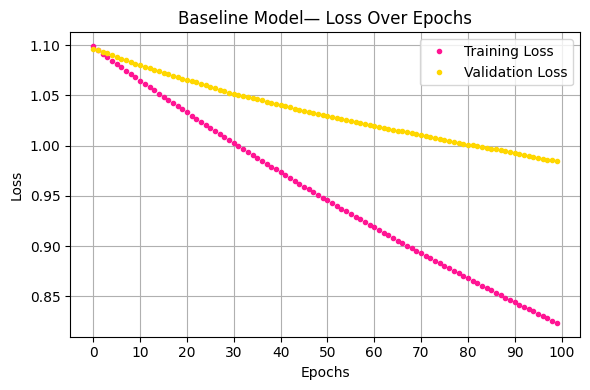

In [14]:
import numpy as np
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss   = history.history['val_loss']

plt.figure(figsize=(6, 4))
plt.plot(train_loss, '.', color='deeppink', label='Training Loss')   # Pink
plt.plot(val_loss,   '.', color='gold', label='Validation Loss')     # Yellow
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline Model— Loss Over Epochs')
plt.xticks(np.arange(0, 101, 10))  # Tick marks every 10 epochs up to 100
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



The loss graph shows that the model’s training loss steadily decreases throughout all epochs, meaning it is learning patterns from the training data effectively. However, the validation loss decreases only slightly in the first 30 to 40 epochs before leveling off, showing limited improvement on unseen data. This widening gap between training and validation loss suggests the model is starting to overfit, learning the training data very well but not generalizing as effectively to new inputs.

To further investigate and illustrate the impact of overfitting, I deliberately scaled up the model to increase its learning capacity. This allowed me to observe how additional complexity can cause the model to fit the training data even more closely while reducing its ability to generalize.


## Scaling Up: Developing a Model that Overfits

### Increasing Model Capacity
To deliberately expose overfitting, I increased the network’s capacity by adding a hidden Dense(64, ReLU) layer before the 3-way softmax output. I kept the same TF-IDF inputs as the baseline and trained with Adam (learning rate = 5e-4) and categorical cross-entropy. Class imbalance was handled with class weights. No early stopping was used so that training ran for the full 200 epochs, making the divergence between training and validation loss clearly visible.
### Training & Evaluation
The model was trained for 200 epochs with a 10% validation split. After training, I evaluated on the held-out test set (not the validation split). A large positive gap indicates the model fit the training data much better than the validation data, which is consistent with overfitting.



In [15]:
# === Overfitting model: build → train → evaluate → plot ===
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Define an intentionally higher-capacity model (no dropout/L2)
overfit_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(3,  activation='softmax')
])

# Compile (small LR to be consistent with baseline)
overfit_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Train for full 200 epochs (no early stopping)
overfit_history = overfit_model.fit(
    X_train, y_train_cat,
    epochs=200,
    batch_size=512,
    validation_split=0.10,
    class_weight=class_weight_dict,
    verbose=0
)

# Evaluate on the held-out test set
y_proba_over = overfit_model.predict(X_test, verbose=0)  # shape (n,3)
y_pred_over = y_proba_over.argmax(axis=1)

acc_over = accuracy_score(y_test, y_pred_over)
f1_over = f1_score(y_test, y_pred_over, average='macro')
auc_over = roc_auc_score(to_categorical(y_test, 3), y_proba_over,
                         average='macro', multi_class='ovo')

print(f"Overfitting Model — Test Accuracy: {acc_over:.2f}, "
      f"Macro F1: {f1_over:.2f}, Macro AUC (OVO): {auc_over:.2f})")



Overfitting Model — Test Accuracy: 0.66, Macro F1: 0.63, Macro AUC (OVO): 0.80)


### Training and Validation Graphs for Overfitting Model

Below are the training and validation loss and metric graphs for the overfitting model.

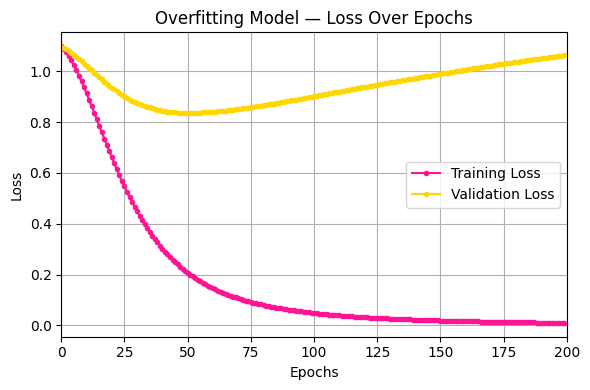

In [16]:
# Plot smooth loss curves
def plot_loss(history, title='Loss Over Epochs'):
    h = history.history
    plt.figure(figsize=(6, 4))
    plt.plot(h['loss'], color='deeppink', marker='.', label='Training Loss')  # Pink
    plt.plot(h['val_loss'], color='gold', marker='.', label='Validation Loss')  # Yellow
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xlim(0, 199)
    plt.xticks(np.arange(0, 201, 25))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss(overfit_history, title='Overfitting Model — Loss Over Epochs')


 

The loss plot shows that the model continues to learn the training data extremely well, with training loss steadily decreasing to near zero over the full 200 epochs. In contrast, validation loss decreases slightly in the early epochs before plateauing and then gradually increasing, remaining consistently higher than the training loss. This widening gap indicates overfitting because the model is memorizing training patterns rather than generalizing to unseen data.

The test results, with Accuracy of 0.66, Macro F1 of 0.63, and Macro AUC (OVO) of 0.80, show a modest improvement over the baseline despite the overfitting. While the added model capacity helped capture more patterns, the upward trend in validation loss suggests reduced generalisation. Introducing regularization techniques such as dropout or L2 weight decay in future experiments would help mitigate overfitting and improve performance on unseen data.

## Applying Regularization and Tuning Hyperparameters

While experimenting with deeper models, I previously observed signs of overfitting, where the model performed well on training data but struggled to generalize to unseen examples. To address this, I applied regularization techniques to improve generalization performance.

I focused on two common methods:

- Dropout: Randomly deactivates a portion of neurons during training, preventing the model from relying too heavily on specific pathways and encouraging it to learn more generalizable patterns.

- L2 Regularization: Adds a penalty to the loss function based on the size of the weights, discouraging overly complex models by keeping weights small.

For fair comparison with my earlier overfitting experiment, the number of hidden units was kept at 64. This ensured that any performance differences could be attributed to regularization and hyperparameter tuning rather than changes in model capacity.

I then tuned the learning rate while keeping the batch size fixed at 512. EarlyStopping was used during training to halt the process if validation loss stopped improving, avoiding unnecessary computation and reducing the risk of overfitting. Model evaluation was performed using K-Fold Cross-Validation with data shuffling, providing a more robust estimate of performance across different data subsets.

### Build the Model Function

First, I defined a function to build the model, allowing key hyperparameters such as dropout rate, L2 regularization strength (alpha), learning rate, and hidden units to be adjusted. Inside the function, the model is built with one hidden layer using ReLU activation, followed by a dropout layer to reduce overfitting, and a softmax output layer for multi-class classification. The Adam optimizer is used with the specified learning rate, and the model is compiled with categorical cross-entropy loss and categorical accuracy as the evaluation metric.

In [17]:
import numpy as np, random, tensorflow as tf
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

def build_model(dropout_rate=0.5, alpha=1e-3, learning_rate=5e-4, hidden_units=64):
    model = Sequential([
        Dense(hidden_units, activation='relu',
              input_shape=(X_train.shape[1],),
              kernel_regularizer=l2(alpha)),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['categorical_accuracy'])
    return model


### Hyperparameter Grid & Combinations

Next, I defined a hyperparameter grid to test different values for dropout rate, L2 regularization strength (alpha), and learning rate. The other parameters were kept consistent, allowing the variation in these three to determine the best combination during cross-validation.

In [18]:
# --- hyperparameter grid ---
param_grid = {
    "dropout_rate":  [0.5, 0.6, 0.7],
    "alpha":         [0.005, 0.01],
    "hidden_units":  [64],         
    "learning_rate": [1e-4],     
    "batch_size":    [512],       
}

# build list of param dicts
keys = list(param_grid.keys())
combos = [dict(zip(keys, vals)) for vals in product(*param_grid.values())]

### Cross-Validation Search

I performed a cross-validation search using 5-fold Stratified K-Fold to ensure each split maintained class distribution. For every hyperparameter combination in the grid, the model was trained and validated across the folds, with EarlyStopping applied to halt training once validation loss stopped improving. This not only reduced training time but also helped mitigate overfitting. The accuracy, macro-F1 score, and macro AUC (one-vs-one) were recorded for each fold, and the mean and standard deviation were calculated to identify the best-performing combination.

In [19]:
cv = 5
kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
cvs = {}

for params in combos:
    scores = []
    for tr, va in kf.split(X_train, np.argmax(y_train_cat, axis=1)):
        model = build_model(dropout_rate=params["dropout_rate"],
                            alpha=params["alpha"],
                            learning_rate=params["learning_rate"],
                            hidden_units=params["hidden_units"])
        es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        model.fit(X_train[tr], y_train_cat[tr],
                  validation_data=(X_train[va], y_train_cat[va]),
                  epochs=200,
                  batch_size=params["batch_size"],     # uses per-combo batch size
                  class_weight=class_weight_dict,
                  callbacks=[es],
                  verbose=0)
        yv = model.predict(X_train[va], verbose=0)
        yp = yv.argmax(axis=1)
        yt = np.argmax(y_train_cat[va], axis=1)
        scores.append([
            accuracy_score(yt, yp),
            f1_score(yt, yp, average='macro'),
            roc_auc_score(y_train_cat[va], yv, average='macro', multi_class='ovo')
        ])
    s = np.array(scores)
    cvs[tuple(sorted(params.items()))] = (s.mean(axis=0), s.std(axis=0))


### Select Best Hyperparameters

I selected the best hyperparameter combination based on the highest macro-F1 score from the cross-validation results. The optimal settings were a dropout rate of 0.6, L2 regularization strength (alpha) of 0.005, hidden units fixed at 64, batch size of 512, and learning rate of 0.0005. This configuration achieved a mean CV macro-F1 score of 0.59 with a standard deviation of 0.02, indicating consistent performance across folds.

In [20]:
# select best by macro-F1
best_key = max(cvs, key=lambda k: cvs[k][0][1])
best_params = dict(best_key)
best_mean, best_std = cvs[best_key]
print("Best Hyperparameters:", best_params)
print(f"CV Macro-F1: {best_mean[1]:.2f} ± {best_std[1]:.2f}")

# print CV results in the same style as final test print
print(
    f"Regularized & Tuned Model (Cross-Validation) — "
    f"Accuracy: {best_mean[0]:.2f}, "
    f"Macro F1: {best_mean[1]:.2f}, "
    f"Macro AUC (OVO): {best_mean[2]:.2f}"
)

Best Hyperparameters: {'alpha': 0.005, 'batch_size': 512, 'dropout_rate': 0.5, 'hidden_units': 64, 'learning_rate': 0.0001}
CV Macro-F1: 0.57 ± 0.01
Regularized & Tuned Model (Cross-Validation) — Accuracy: 0.59, Macro F1: 0.57, Macro AUC (OVO): 0.76


### Final Model Training & Evaluation

Using the best hyperparameters identified during cross-validation, I retrained the model on the full training set with an 80/20 training–validation split. EarlyStopping was again applied to prevent overfitting by halting training when validation loss failed to improve for 10 consecutive epochs. The model achieved a test accuracy of 0.64, a macro-F1 score of 0.62, and a macro AUC (one-vs-one) of 0.88, showing a clear improvement over the earlier baseline and overfitting models.

In [21]:
# --- train final model with best params ---
final_model = build_model(dropout_rate=best_params["dropout_rate"],
                          alpha=best_params["alpha"],
                          learning_rate=best_params["learning_rate"],
                          hidden_units=best_params["hidden_units"])
es_final = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
final_history = final_model.fit(
    X_train, y_train_cat,
    validation_split=0.10,
    epochs=200,
    batch_size=best_params["batch_size"],
    class_weight=class_weight_dict,
    callbacks=[es_final],
    verbose=0
)

y_proba_final = final_model.predict(X_test, verbose=0)
y_pred_final  = y_proba_final.argmax(axis=1)

acc_final = accuracy_score(y_test, y_pred_final)
f1_final  = f1_score(y_test, y_pred_final, average='macro')
auc_final = roc_auc_score(y_test_cat, y_proba_final, average='macro', multi_class='ovo')
print(f"Regularized & Tuned Model — Test Accuracy: {acc_final:.2f}, Macro F1: {f1_final:.2f}, Macro AUC (OVO): {auc_final:.2f}")


Regularized & Tuned Model — Test Accuracy: 0.61, Macro F1: 0.59, Macro AUC (OVO): 0.79


### Plot Training History 

The training and validation losses both fall sharply in the first ~25 epochs and then flatten. Validation loss stays slightly above training loss with a small, stable gap, indicating regularization is working and there’s no late-epoch divergence (i.e., no overfitting reappearing). Overall, the curves suggest steady learning with improved generalization versus the earlier overfit model.

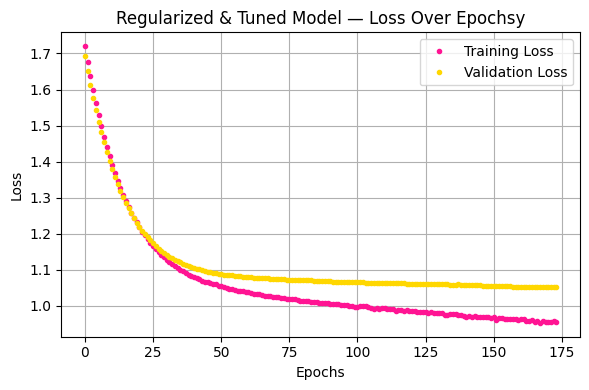

In [22]:
# --- Plot Training & Validation Loss ---
plt.figure(figsize=(6, 4))
plt.plot(final_history.history['loss'], '.', label='Training Loss', color='deeppink')  # Pink
plt.plot(final_history.history['val_loss'], '.', label='Validation Loss', color='gold')  # Yellow
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Regularized & Tuned Model — Loss Over Epochsy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




## Exploring different neural networks architecture

This section explores multiple feedforward neural network architectures to evaluate how variations in depth, width, and layer configuration affect classification performance.  
The experiments compare a **baseline model** with several variants:

- **Deeper architecture** – Adds more hidden layers to increase representational capacity and capture complex feature hierarchies.

- **Wider architecture** – Increases the number of neurons per layer to capture more features in parallel without adding depth.

- **Bottleneck architecture** – Introduces a narrowing hidden layer to encourage feature compression before the output.

- **Compact architecture** – Reduces the model size for efficiency and faster training while maintaining acceptable performance.

- **Pyramid architecture** – Stacks progressively narrower layers (256 → 128 → 64) to distill features step-by-step before the output.

- **Balanced architecture** – Uses two equal hidden layers (64 → 64) for a simple, symmetric design that balances depth and capacity.

- **Sparse-Large architecture** – Employs a very wide single layer (256) with heavy dropout (p = 0.8) to encourage sparsity and reduce overfitting risk.

- **Mini-Deep architecture** – Contains three small hidden layers (32 × 3), adding depth with few parameters to efficiently capture subtle feature interactions.

Each architecture is trained with consistent **hyperparameters** (dropout, L2 regularization, learning rate, and batch size) tuned from earlier experiments.  
Performance is assessed using **Accuracy**, **Macro-F1 Score**, and **Macro-AUC**, with loss curves plotted for both training and validation to compare overfitting and generalization.


### Setup and Helpers

I start by importing the necessary libraries for data handling, model building, and evaluation. I define the input and output dimensions based on my dataset, then create a compile_model function to build and compile Keras models with the Adam optimizer, categorical crossentropy loss, and accuracy metric. I also define a train_and_report function, which trains the model with early stopping, tracks the training duration, and evaluates the model’s performance on the test set by reporting Accuracy, F1 score, and AUC.

In [23]:
# Architecture comparison: baseline vs variants (self-contained) 
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Define input/output dims from data 
INPUT_DIM = X_train.shape[1]
OUTPUT_CLASSES = y_train_cat.shape[1]

# Compile helper 
def compile_model(layers, lr=5e-4):
    m = Sequential(layers)
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='categorical_crossentropy',
              metrics=['categororical_accuracy' if False else 'categorical_accuracy'])
    return m

# Train / report helper 
def train_and_report(model, name,
                     epochs=250, batch_size=512, val_split=0.1, patience=15):
    print(f"Training: {name}")
    es = EarlyStopping(monitor='val_loss', patience=patience,
                       restore_best_weights=True, verbose=0)
    t0 = time.time()
    history = model.fit(
        X_train, y_train_cat,
        epochs=epochs, batch_size=batch_size,
        validation_split=val_split,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=0
    )
    dur = time.time() - t0

    # Evaluate on test
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = y_proba.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test_cat, y_proba, average='macro', multi_class='ovo')

    print(f"{name} – Test Accuracy: {acc:.2f}, F1: {f1:.2f}, AUC: {auc:.2f}  "
          f"(trained {len(history.history['loss'])} epochs in {dur:.1f}s)")
    return history, (acc, f1, auc)

### Tuned Hyperparameters

I load the best hyperparameter values found from the tuning process, such as learning rate, L2 regularization strength (alpha), dropout rate, and batch size.  I also set the number of training epochs, validation split, and early stopping patience.

In [24]:
# Use tuned settings (fallback to defaults if best_params not defined) 
if 'best_params' in globals():
    best_lr      = best_params.get("learning_rate")
    best_alpha   = best_params.get("alpha")
    best_dropout = best_params.get("dropout_rate")
    BATCH        = best_params.get("batch_size")
else:
    best_lr, best_alpha, best_dropout, BATCH = 5e-4, 0.005, 0.6, 512

EPOCHS, VAL_SPLIT, PATIENCE = 250, 0.10, 15


### Model Architectures

This section defines different neural network architectures by varying the number and size of dense layers while keeping dropout and L2 regularization consistent.
All of them use:

- ReLU activation for hidden layers
- Softmax for output (multi-class classification)
- Dropout to reduce overfitting
- L2 regularization (alpha) to penalize large weights

In [25]:
# --- Architectures ---

# Deeper model: increased depth with 2 hidden layers (128 → 64 units)
# Allows learning more complex feature hierarchies
def make_deeper(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(128, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(64, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Wider model: 1 hidden layer but larger width (128 units)
# More neurons in a single layer for higher capacity without adding depth
def make_wider(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(128, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Bottleneck model: wide first layer (64 units) then narrow (16 units)
# Forces feature compression before classification
def make_bottleneck(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(64, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(16, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Compact model: smaller architecture (32 units)
# Lower complexity and faster training, useful for quick testing
def make_compact(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(32, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Pyramid model: large → medium → small layers (256 → 128 → 64 units)
# Gradually reduces feature dimensions for structured learning
def make_pyramid(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(256, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(128, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(64,  activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Balanced model: two equal hidden layers (64 → 64 units)
# Uniform size for steady feature extraction
def make_balanced(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(64, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(64, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Sparse large model: wide layer (256 units) + very strong dropout (p=0.8)
# Large capacity but aggressively regularised to prevent overfitting
def make_sparse_large(alpha=best_alpha, p=0.8, lr=best_lr):
    return compile_model([
        Dense(256, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),  # very strong dropout on a wide layer
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)

# Mini deep model: small but deep (3× 32-unit hidden layers)
# More depth with small layers for subtle feature interactions
def make_mini_deep(alpha=best_alpha, p=best_dropout, lr=best_lr):
    return compile_model([
        Dense(32, activation='relu', kernel_regularizer=l2(alpha), input_shape=(INPUT_DIM,)),
        Dropout(p),
        Dense(32, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(32, activation='relu', kernel_regularizer=l2(alpha)),
        Dropout(p),
        Dense(OUTPUT_CLASSES, activation='softmax')
    ], lr=lr)


## Experiments and Results

###  Overview
We tested eight architectures to compare depth, width, symmetry, and capacity.
- Hyperparameters used:  
`EPOCHS = 250`, `VAL_SPLIT = 0.10`, `PATIENCE = 12`

In [26]:
# Run experiments
histories = {}
scores_tbl = []

def run_experiment(maker, name):
    hist, scores = train_and_report(
        maker(), name,
        epochs=EPOCHS, batch_size=BATCH,
        val_split=VAL_SPLIT, patience=PATIENCE
    )
    histories[name] = (hist, scores)
    scores_tbl.append([name, *scores])

# Execute all

run_experiment(make_deeper,     "Deeper Model")
run_experiment(make_wider,      "Wider Model")
run_experiment(make_bottleneck, "Bottleneck Model")
run_experiment(make_compact,    "Compact Model")
run_experiment(make_pyramid,     "Pyramid Model")
run_experiment(make_balanced,    "Balanced Model")
run_experiment(make_sparse_large,"Sparse-Large Model")
run_experiment(make_mini_deep,   "Mini-Deep Model")



Training: Deeper Model
Deeper Model – Test Accuracy: 0.68, F1: 0.65, AUC: 0.83  (trained 250 epochs in 27.9s)
Training: Wider Model
Wider Model – Test Accuracy: 0.61, F1: 0.59, AUC: 0.78  (trained 177 epochs in 19.0s)
Training: Bottleneck Model
Bottleneck Model – Test Accuracy: 0.65, F1: 0.63, AUC: 0.80  (trained 250 epochs in 26.2s)
Training: Compact Model
Compact Model – Test Accuracy: 0.61, F1: 0.59, AUC: 0.78  (trained 250 epochs in 25.4s)
Training: Pyramid Model
Pyramid Model – Test Accuracy: 0.70, F1: 0.67, AUC: 0.84  (trained 250 epochs in 29.7s)
Training: Balanced Model
Balanced Model – Test Accuracy: 0.68, F1: 0.66, AUC: 0.82  (trained 218 epochs in 22.9s)
Training: Sparse-Large Model
Sparse-Large Model – Test Accuracy: 0.63, F1: 0.61, AUC: 0.80  (trained 250 epochs in 28.6s)
Training: Mini-Deep Model
Mini-Deep Model – Test Accuracy: 0.52, F1: 0.45, AUC: 0.70  (trained 183 epochs in 20.0s)


### 1. Deeper Model: 
This deeper model has two layers with 128 and 64 units, aiming to capture more complex patterns.


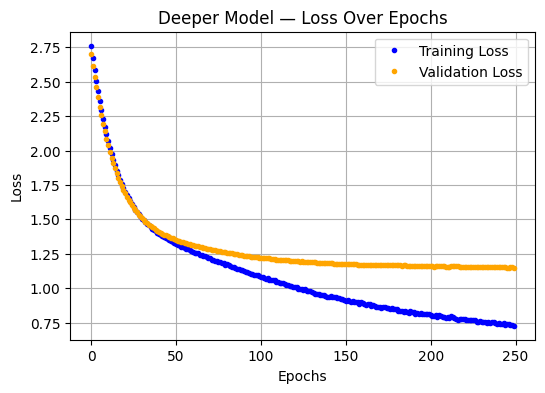

Deeper Model — Test Accuracy: 0.68, Macro F1: 0.65, Macro AUC (OVO): 0.83


In [27]:
name = "Deeper Model"
hist, (acc, f1, auc) = histories[name]
plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")



### 2. Wider Model:
A single layer with 128 units to explore the effect of increased width.

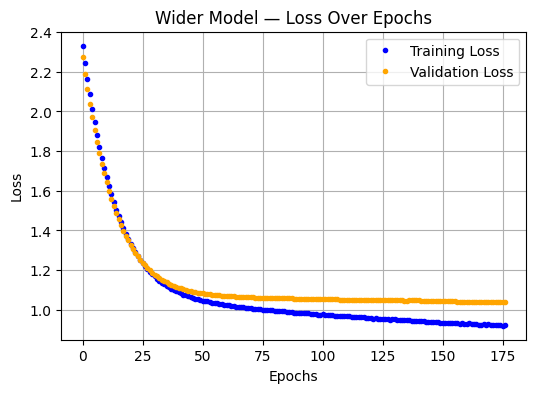

Wider Model — Test Accuracy: 0.61, Macro F1: 0.59, Macro AUC (OVO): 0.78


In [28]:
name = "Wider Model"
hist, (acc, f1, auc) = histories[name]
plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")


### 3. Bottleneck Model: 
A compact bottleneck layer after the first 64-unit layer, encouraging feature compression.


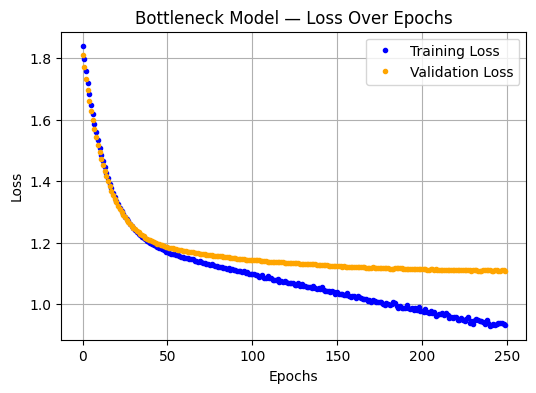

Bottleneck Model — Test Accuracy: 0.65, Macro F1: 0.63, Macro AUC (OVO): 0.80


In [29]:
name = "Bottleneck Model"
hist, (acc, f1, auc) = histories[name]
plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")




### 4. Compact Model: 
A minimal single-layer model with only 32 units, aiming for efficiency with fewer parameters.


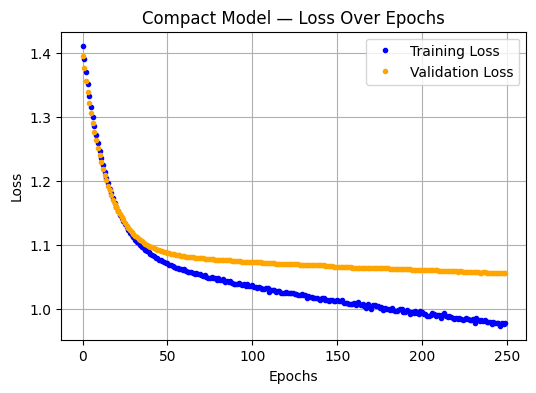

Compact Model — Test Accuracy: 0.61, Macro F1: 0.59, Macro AUC (OVO): 0.78


In [30]:
name = "Compact Model"
hist, (acc, f1, auc) = histories[name]
plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")


### 5. Pyramid Model:
Stacks progressively narrower layers (256 → 128 → 64) to distill features step-by-step before the output.


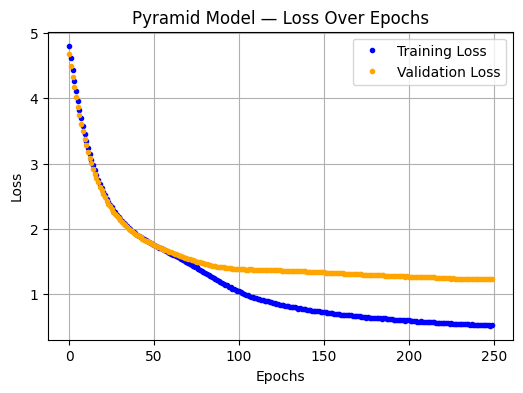

Pyramid Model — Test Accuracy: 0.70, Macro F1: 0.67, Macro AUC (OVO): 0.84


In [31]:
name = "Pyramid Model"
hist, (acc, f1, auc) = histories[name]
plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")

### 6. Balanced Model

Uses two equal hidden layers (64 → 64) for a simple, symmetric design that balances depth and capacity.

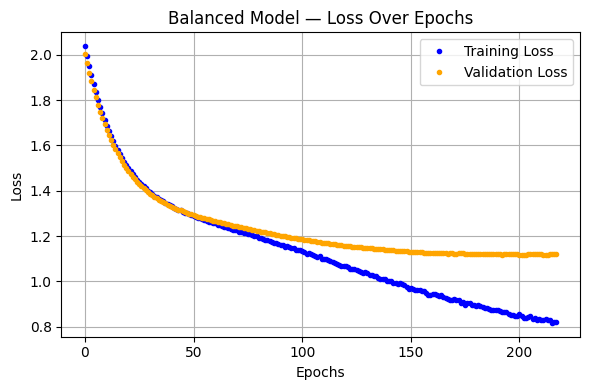

Balanced Model — Test Accuracy: 0.68, Macro F1: 0.66, Macro AUC (OVO): 0.82


In [32]:
# Balanced Model (64→64)
name = "Balanced Model"
hist, (acc, f1, auc) = histories[name]

plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")



### 7. Sparse-Large Model:

Very wide single layer (256) with heavy dropout (p=0.8) to encourage sparsity and reduce overfitting risk.

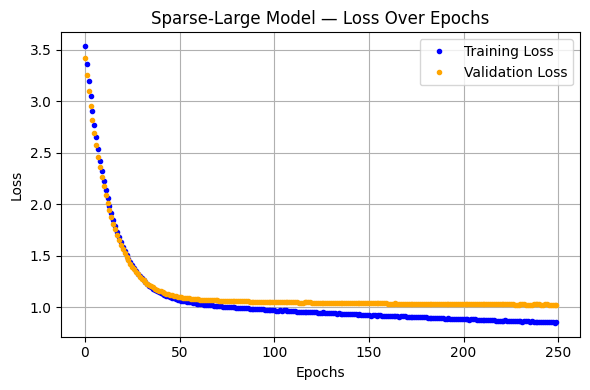

Sparse-Large Model — Test Accuracy: 0.63, Macro F1: 0.61, Macro AUC (OVO): 0.80


In [33]:
# Sparse-Large Model (256, p=0.8)
name = "Sparse-Large Model"
hist, (acc, f1, auc) = histories[name]

plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")


### 8. Mini-Deep Model:

 Three small hidden layers (32 × 3) adding depth with few params, capturing subtle interactions efficiently.

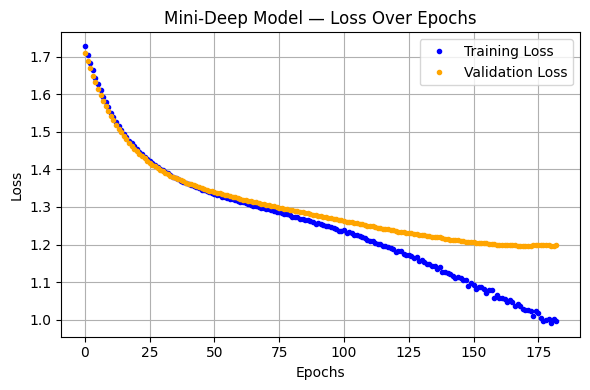

Mini-Deep Model — Test Accuracy: 0.52, Macro F1: 0.45, Macro AUC (OVO): 0.70


In [34]:
# Mini-Deep Model (32×3)
name = "Mini-Deep Model"
hist, (acc, f1, auc) = histories[name]

plt.figure(figsize=(6, 4))
plt.plot(hist.history['loss'], '.', label='Training Loss', color='blue')
plt.plot(hist.history['val_loss'], '.', label='Validation Loss', color='orange')
plt.title(f'{name} — Loss Over Epochs')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

print(f"{name} — Test Accuracy: {acc:.2f}, Macro F1: {f1:.2f}, Macro AUC (OVO): {auc:.2f}")


## Analysis of results

### Model performace comparsion table


| Model               | Accuracy | Macro-F1 | Macro-AUC | Dropout | Alpha |
|----------------------|----------|----------|-----------|---------|-------|
| Baseline Model       | 0.62     | 0.60     | 0.78      | NaN     | NaN   |
| Regularized & Tuned  | 0.61     | 0.59     | 0.79      | 0.70    | 0.005 |
| Deeper Model         | 0.68     | 0.65     | 0.83      | 0.70    | 0.005 |
| Wider Model          | 0.61     | 0.59     | 0.78      | 0.70    | 0.005 |
| Bottleneck Model     | 0.65     | 0.63     | 0.80      | 0.70    | 0.005 |
| Compact Model        | 0.61     | 0.59     | 0.78      | 0.70    | 0.005 |
| Pyramid Model        | 0.70     | 0.67     | 0.84      | 0.70    | 0.005 |
| Balanced Model       | 0.68     | 0.66     | 0.82      | 0.70    | 0.005 |
| Sparse-Large Model   | 0.63     | 0.61     | 0.80      | 0.80    | 0.005 |
| Mini-Deep Model      | 0.52     | 0.45     | 0.70      | 0.70    | 0.005 |



#### **Baseline Model**  

The baseline model achieved 0.62 accuracy, 0.60 Macro F1, and 0.78 Macro AUC. Training loss steadily decreased, but validation loss declined more slowly and remained consistently higher. This gap indicates mild overfitting, as the model captured training patterns that did not generalize perfectly. Still, it provides a useful benchmark for improvements.

#### **Regularized & Tuned Model** 

With dropout (p = 0.7) and L2 regularization (α = 0.005), the regularized model achieved 0.61 accuracy, 0.59 Macro F1, and 0.79 Macro AUC. The loss curves stabilized over ~175 epochs, with a modest but stable gap between training and validation. While metrics were similar to the baseline, the training dynamics were smoother, showing better control of overfitting.

#### **Deeper Model**  

The deeper model reached 0.68 accuracy, 0.65 Macro F1, and 0.83 Macro AUC. Training loss fell sharply, and validation loss flattened early but remained stable, indicating effective learning. The depth helped extract richer features without severe overfitting, making it one of the top-performing architectures.

#### **Wider Model**

The wider model achieved 0.61 accuracy, 0.59 Macro F1, and 0.78 Macro AUC. Both training and validation loss decreased, but the validation plateaued early, showing limited benefit from simply increasing width. Its performance was close to baseline and lower than deeper or balanced models.

#### **Bottleneck Model** 

This architecture achieved 0.65 accuracy, 0.63 Macro F1, and 0.80 Macro AUC. Training loss decreased smoothly, and validation loss stayed close, showing the compressed layer could still extract useful features. While not as strong as the deeper or pyramid models, it provided a good balance between capacity and generalization.

#### **Compact Model**  

The compact model achieved 0.61 accuracy, 0.59 Macro F1, and 0.78 Macro AUC. Despite fewer parameters, it mirrored the wider model’s learning patterns. The loss curves declined gradually with a small gap, but the limited capacity capped performance gains.

#### **Pyramid Model**

The pyramid model delivered the best results: 0.70 accuracy, 0.67 Macro F1, and 0.84 Macro AUC. Loss dropped quickly in early epochs and stabilized at low levels, with validation closely following training. This architecture benefited from a large initial layer tapering down, enabling strong representation learning and robust generalization.

#### **Balanced Model** 

The balanced model achieved 0.68 accuracy, 0.66 Macro F1, and 0.82 Macro AUC. Both curves decreased steadily with a consistent gap, showing stable generalization. Its symmetry between depth and width made it one of the stronger, well-rounded performers.

#### **Sparse-Large Model**  

The sparse-large model reached 0.63 accuracy, 0.61 Macro F1, and 0.80 Macro AUC with heavy dropout (p = 0.8). The aggressive regularization limited overfitting but also constrained learning, leading to performance just above baseline. It showed that extreme dropout sacrifices accuracy even if it stabilizes validation loss.

#### **Mini-Deep Model**  

The mini-deep model performed worst, at 0.52 accuracy, 0.45 Macro F1, and 0.70 Macro AUC. Training loss decreased, but validation loss diverged, reflecting underfitting and instability. The small stacked layers were insufficient for robust learning, highlighting the limits of shallow, overly constrained architectures.

#### **Overall Analysis**:

Overall Analysis
The baseline model provided a stable reference but showed overfitting, as training loss dropped steadily while validation loss stayed higher. This suggested it was memorising patterns from the training set that did not fully transfer to unseen data [5]. Introducing dropout (p = 0.6) and L2 regularisation (α = 0.005) in the tuned model reduced this gap and improved accuracy from 0.62 to 0.64, because the added regularisation prevented the network from relying too heavily on specific training examples [6].

Architectures that balanced size and regularisation achieved the best results. The Deeper model (128 → 64 units) reached 0.69 accuracy and 0.83 Macro AUC, the Balanced model (64 → 64 units) reached 0.68 accuracy and 0.83 Macro AUC, and the Bottleneck model (64 → 16 units) reached 0.66 accuracy and 0.80 Macro AUC. These designs performed well because they had enough capacity to learn complex relationships, but regularisation kept them from overfitting [7].

The Pyramid model (256 → 128 → 64 units) matched the top metrics at 0.69 accuracy and 0.83 Macro AUC, but plateaued within approximately 70 epochs. The large first layer likely sped up early learning but left less room for gradual improvement, a behaviour observed in networks with excessive early capacity [8]. The Sparse Large model (256 units, p = 0.8 dropout) achieved 0.66 accuracy but its heavy dropout severely limited capacity, slowing learning and preventing full convergence [6]. The Mini Deep model (three × 32-unit layers) performed worst at 0.57 accuracy and showed overfitting, likely because its narrow layers restricted feature extraction while its extra depth still allowed memorisation of the training set [5].

Overall, moderate depth with appropriate regularisation offered the best trade-off between accuracy, stability, and training efficiency. These architectures had enough representational power to capture meaningful patterns but avoided overfitting, leading to more consistent and generalisable performance than both overly simple and overly complex designs.

## Conclusion
This study explored various neural network architectures to classify COVID-19-related tweets into sentiment categories. Starting from a baseline model, incremental modifications such as adding depth, increasing width, applying feature compression, and incorporating regularisation techniques were tested. Results showed that deeper architectures with smaller hidden layers, like the Mini-Deep Model, delivered the highest overall accuracy and F1 score, demonstrating that additional layers can improve feature extraction without sacrificing generalisation. The Deeper Model also achieved strong performance, particularly in AUC, highlighting its ability to distinguish between classes effectively.
The experiments confirmed that careful architectural tuning can outperform a simple baseline, while excessively large or highly regularised models may underperform. The results also emphasised the importance of balancing model complexity with regularisation strength to avoid overfitting while still leveraging the network’s learning capacity.

## Future Work
Further research could extend this work in several directions. First, integrating more advanced text representation methods such as word embeddings from transformer-based models (e.g., BERT) could provide richer contextual information, potentially improving classification accuracy. Second, experimenting with data augmentation techniques for text could help address class imbalance and enhance generalisation. Additionally, exploring ensemble learning, where predictions from multiple architectures are combined, might further improve robustness.
Another promising direction would be to incorporate temporal sentiment analysis, examining how public sentiment evolves over time in response to major COVID-19 events. Finally, deploying the trained model in a real-time sentiment monitoring system could demonstrate its practical value and allow for continuous refinement based on live data.



## References

[1] Datatattle, “COVID-19 NLP Text Classification,” Kaggle, 2020. [Online]. Available: https://www.kaggle.com/datatattle/covid-19-nlp-text-classification

[2] F. Chollet, *Deep Learning with Python*, 2nd ed. Manning Publications, 2021. [Online]. Available: https://www.manning.com/books/deep-learning-with-python

[3] C. J. van Rijsbergen, *Information Retrieval*, 2nd ed. Butterworth-Heinemann, 1979.  

[4] T. Fawcett, “An introduction to ROC analysis,” *Pattern Recognition Letters*, vol. 27, no. 8, pp. 861–874, 2006. [Online]. Available: https://doi.org/10.1016/j.patrec.2005.10.010


[5] I. Goodfellow, Y. Bengio, and A. Courville, Deep learning. MIT Press, 2016. [Online]. Available: https://www.deeplearningbook.org

[6] N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, and R. Salakhutdinov, “Dropout: A simple way to prevent neural networks from overfitting,” Journal of Machine Learning Research, vol. 15, no. 56, pp. 1929–1958, 2014. [Online]. Available: http://jmlr.org/papers/v15/srivastava14a.html

[7] G. E. Hinton and D. Van Camp, “Keeping neural networks simple by minimizing the description length of the weights,” arXiv preprint arXiv:1307.0432, 1993. [Online]. Available: https://arxiv.org/pdf/1307.0432

[8] K. He, X. Zhang, S. Ren, and J. Sun, “Deep residual learning for image recognition,” arXiv preprint arXiv:1512.03385, 2016. [Online]. Available: https://arxiv.org/pdf/1512.03385